In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/customer-churn-ml-project/Telco-Customer-Churn.csv'
df=pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(df.isnull().sum())
print(df.describe())
df.info()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
D

No null value present

**Univariate Analysis**

In [3]:
#performed on categorical data
print(df['Churn'].value_counts())
print(df['tenure'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64


The target variable is in the parts of 73-28 percent and count of 1 month tenure is higher

<Axes: xlabel='tenure', ylabel='Count'>

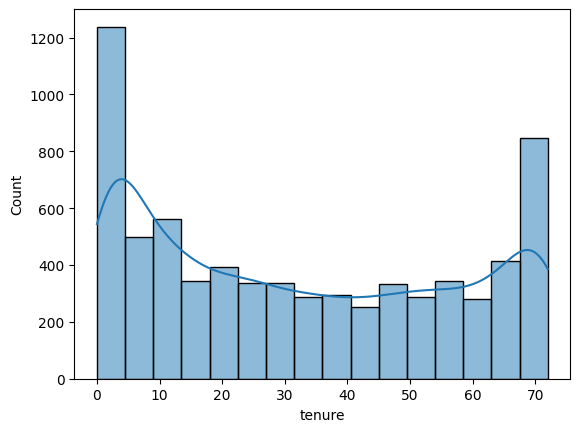

In [4]:
sns.histplot(df['tenure'], kde=True)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

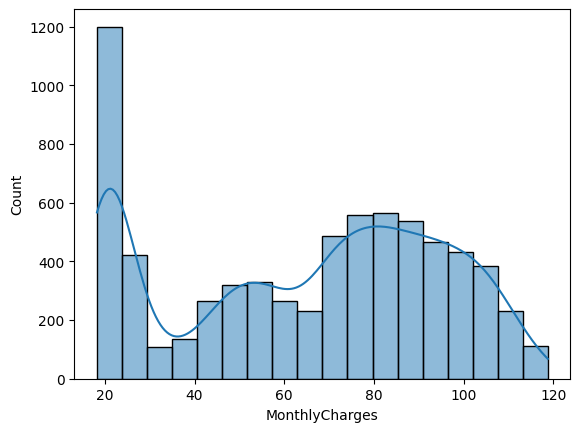

In [5]:
sns.histplot(df['MonthlyCharges'], kde=True)

<Axes: >

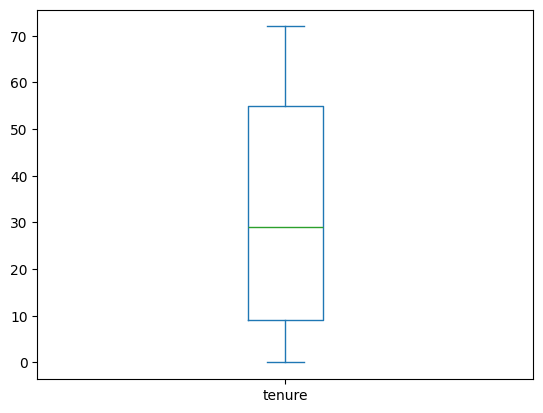

In [6]:
df['tenure'].skew() #reprents the data which on same level, less skewness
df['tenure'].plot(kind='box')

**Bivariate Analysis**

In [7]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


less months leads to more churn rate

In [8]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


fiber optic service users' churn rate is more

In [9]:
pd.crosstab(df['OnlineSecurity'], df['Churn'])

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


with no online security , customer churn more

In [10]:
pd.crosstab(df['TechSupport'], df['Churn'])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


no tech support --> more churn

In [11]:
pd.crosstab(df['PaymentMethod'], df['Churn'])  #doesnot matter mostly

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [12]:
pd.crosstab(df['PaperlessBilling'], df['Churn'])

Churn,No,Yes
PaperlessBilling,,
No,2403,469
Yes,2771,1400


paperless billing had more churn rate

In [13]:
pd.crosstab(df['SeniorCitizen'], df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


younger customers --> more churn

In [14]:
pd.crosstab(df['Partner'], df['Churn'])

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


No partner --> more churn

In [15]:
pd.crosstab(df['Dependents'], df['Churn'])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


**Multi Variate Analysis**

In [16]:
pd.crosstab([df['Contract'], df['InternetService']], df['Churn'])

Churn                            No   Yes
Contract       InternetService           
Month-to-month DSL              829   394
               Fiber optic      966  1162
               No               425    99
One year       DSL              517    53
               Fiber optic      435   104
               No               355     9
Two year       DSL              616    12
               Fiber optic      398    31
               No               633     5

In [17]:
pd.crosstab([df['Contract'], df['OnlineSecurity']], df['Churn'])

Churn                                 No   Yes
Contract       OnlineSecurity                 
Month-to-month No                   1288  1343
               No internet service   425    99
               Yes                   507   213
One year       No                    460    97
               No internet service   355     9
               Yes                   492    60
Two year       No                    289    21
               No internet service   633     5
               Yes                   725    22